In [1]:
import scanpy as sc
from pathlib import Path

data_path = Path("/export/space3/users/silvanac/NeuroNet_AD/data/whole_taxonomy_MTG_AD.h5ad")

# Modo "backed": no carga la matriz de expresión en memoria, solo metadata
adata = sc.read_h5ad(data_path, backed="r")

# # Resumen general de la estructura del AnnData
# print(adata)

# # Dimensiones
# print("\nShape (n_obs x n_vars):", adata.shape)

# # Columnas de obs (metadata por célula)
# print("\nColumnas en obs:")
# print(adata.obs.columns.tolist())

# # Vista rápida de obs
# print("\nHead de obs:")
# print(adata.obs.head())

# Columnas de var (metadata por gen)
# print("\nColumnas en var:")
# print(adata.var.columns.tolist())

# Otras estructuras disponibles
# print("\nobsm keys:", list(adata.obsm.keys()))
# print("varm keys:", list(adata.varm.keys()))
# print("layers keys:", list(adata.layers.keys()))
# print("uns keys:", list(adata.uns.keys()))

# Resumen general de la estructura del AnnData
print(adata)

# Dimensiones
print("\nShape (n_obs x n_vars):", adata.shape)

# Columnas de obs (metadata por célula/núcleo)
print("\nColumnas en obs:")
print(adata.obs.columns.tolist())

# Vista rápida de obs
print("\nHead de obs:")
print(adata.obs.head())



/export/space3/users/rafadiaz/conda_envs/neuronet/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/export/space3/users/rafadiaz/conda_envs/neuronet/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/export/space3/users/rafadiaz/conda_envs/neuronet/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


AnnData object with n_obs × n_vars = 1378211 × 35483 backed at '/export/space3/users/silvanac/NeuroNet_AD/data/whole_taxonomy_MTG_AD.h5ad'
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'Neurotypical reference', 'Class', 'Subclass', 'Supertype', 'Age at death', 'Years of education', 'Cognitive status', 'ADNC', 'Braak stage', 'Thal phase', 'CERAD score', 'APOE4 status', 'Lewy body disease pathology', 'LATE-NC stage', 'Microinfarct pathology', 'Specimen ID', 'donor_id', 'PMI', 'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs', 'suspension_type', 'development_stage_ontology_term_id', 'Continuous Pseudo-progression Score', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_refer

Class                           category
Subclass                        category
Supertype                       category
donor_id                        category
Specimen ID                     category
Number of UMIs                     int64
Genes detected                     int64
Fraction mitochrondrial UMIs     float32
assay                           category
suspension_type                 category
dtype: object
Class                           0
Subclass                        0
Supertype                       0
donor_id                        0
Specimen ID                     0
Number of UMIs                  0
Genes detected                  0
Fraction mitochrondrial UMIs    0
assay                           0
suspension_type                 0
dtype: int64
severity_group
High            42
Intermediate    21
Low             12
Not_AD           9
Name: count, dtype: int64

Donantes sin severidad asignada: 137303


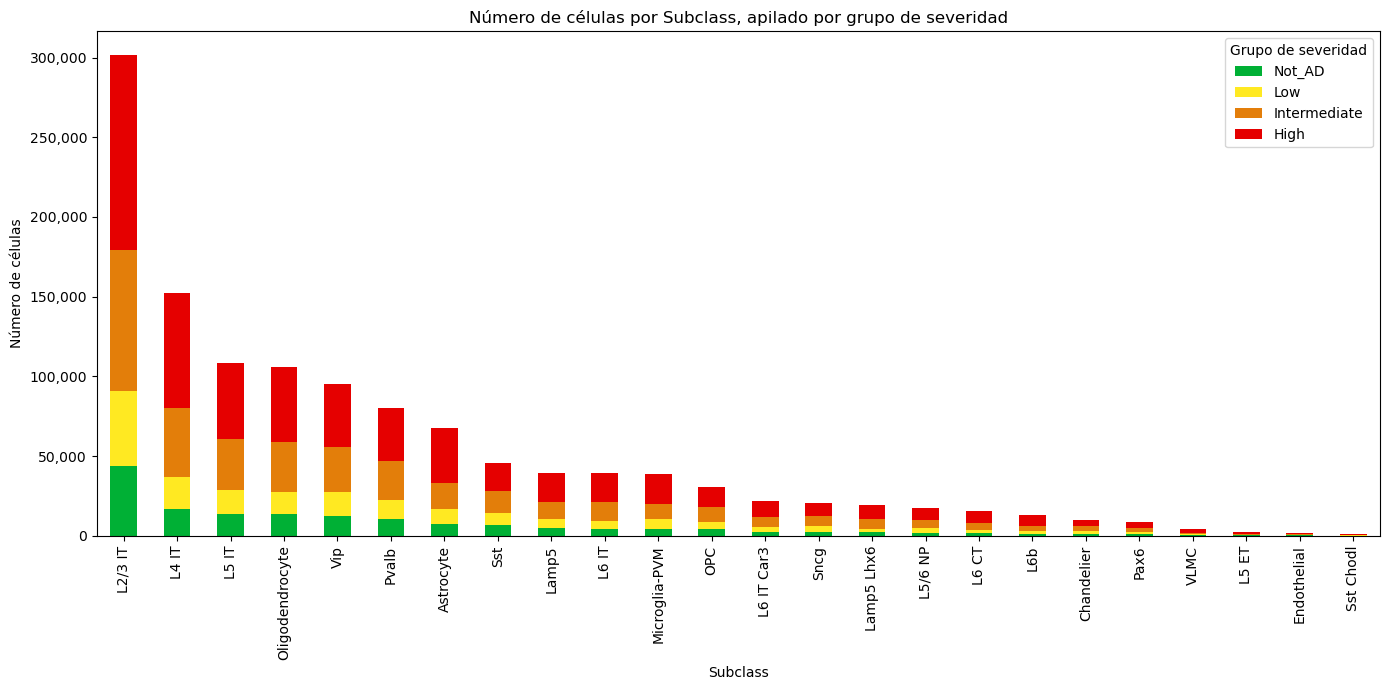

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

cols = ['Class', 'Subclass', 'Supertype', 'donor_id', 'Specimen ID',
        'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs',
        'assay', 'suspension_type']

obs = adata.obs[cols].copy()
print(obs.dtypes)
print(obs.isna().sum())

# Donor ID -> grupo de severidad (extraído de sea-ad_cohort_donor_metadata)
donor_severity_data = [
    ('H19.33.004', 'Not_AD'),
    ('H20.33.001', 'Low'),
    ('H20.33.002', 'Not_AD'),
    ('H20.33.004', 'High'),
    ('H20.33.005', 'Intermediate'),
    ('H20.33.008', 'High'),
    ('H20.33.011', 'High'),
    ('H20.33.012', 'Low'),
    ('H20.33.013', 'Intermediate'),
    ('H20.33.014', 'Intermediate'),
    ('H20.33.015', 'Intermediate'),
    ('H20.33.016', 'Intermediate'),
    ('H20.33.017', 'High'),
    ('H20.33.018', 'High'),
    ('H20.33.019', 'Intermediate'),
    ('H20.33.020', 'High'),
    ('H20.33.024', 'Intermediate'),
    ('H20.33.025', 'High'),
    ('H20.33.026', 'High'),
    ('H20.33.027', 'Intermediate'),
    ('H20.33.028', 'High'),
    ('H20.33.029', 'High'),
    ('H20.33.030', 'High'),
    ('H20.33.031', 'High'),
    ('H20.33.032', 'High'),
    ('H20.33.033', 'High'),
    ('H20.33.034', 'Intermediate'),
    ('H20.33.035', 'Not_AD'),
    ('H20.33.036', 'High'),
    ('H20.33.037', 'High'),
    ('H20.33.038', 'High'),
    ('H20.33.039', 'High'),
    ('H20.33.040', 'Intermediate'),
    ('H20.33.041', 'High'),
    ('H20.33.043', 'Intermediate'),
    ('H20.33.044', 'Not_AD'),
    ('H20.33.045', 'High'),
    ('H20.33.046', 'High'),
    ('H21.33.001', 'Low'),
    ('H21.33.002', 'High'),
    ('H21.33.003', 'Not_AD'),
    ('H21.33.004', 'Not_AD'),
    ('H21.33.005', 'Intermediate'),
    ('H21.33.006', 'Intermediate'),
    ('H21.33.007', 'High'),
    ('H21.33.008', 'High'),
    ('H21.33.009', 'High'),
    ('H21.33.010', 'High'),
    ('H21.33.011', 'Not_AD'),
    ('H21.33.012', 'Intermediate'),
    ('H21.33.013', 'High'),
    ('H21.33.014', 'Intermediate'),
    ('H21.33.015', 'Low'),
    ('H21.33.016', 'Low'),
    ('H21.33.017', 'High'),
    ('H21.33.018', 'Low'),
    ('H21.33.019', 'Low'),
    ('H21.33.020', 'High'),
    ('H21.33.021', 'Intermediate'),
    ('H21.33.022', 'Intermediate'),
    ('H21.33.023', 'Not_AD'),
    ('H21.33.025', 'Intermediate'),
    ('H21.33.026', 'High'),
    ('H21.33.027', 'High'),
    ('H21.33.028', 'Low'),
    ('H21.33.029', 'High'),
    ('H21.33.030', 'Intermediate'),
    ('H21.33.031', 'High'),
    ('H21.33.032', 'Low'),
    ('H21.33.033', 'High'),
    ('H21.33.034', 'High'),
    ('H21.33.035', 'High'),
    ('H21.33.036', 'High'),
    ('H21.33.037', 'Low'),
    ('H21.33.038', 'Low'),
    ('H21.33.039', 'High'),
    ('H21.33.040', 'High'),
    ('H21.33.041', 'Not_AD'),
    ('H21.33.042', 'High'),
    ('H21.33.043', 'Low'),
    ('H21.33.044', 'Intermediate'),
    ('H21.33.045', 'High'),
    ('H21.33.046', 'High'),
    ('H21.33.047', 'Intermediate'),
]

donor_severity = pd.DataFrame(donor_severity_data, columns=['donor_id', 'severity_group'])
print(donor_severity['severity_group'].value_counts())

# Merge contra obs (por donor_id)
obs_con_severidad = obs.merge(donor_severity, on='donor_id', how='left')
print("\nDonantes sin severidad asignada:", obs_con_severidad['severity_group'].isna().sum())

# Tabla Subclass x severidad
orden_severidad = ['Not_AD', 'Low', 'Intermediate', 'High']
tabla = obs_con_severidad.groupby(['Subclass', 'severity_group'], observed=True).size().unstack(fill_value=0)
tabla = tabla[orden_severidad]
tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]

# Gráfico
colores = ["#00B035", "#FFE922", "#E37E0A", "#E50000"]

ax = tabla.plot(kind='bar', stacked=True, figsize=(14, 7), color=colores)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
plt.title('Número de células por Subclass, apilado por grupo de severidad')
plt.xlabel('Subclass')
plt.ylabel('Número de células')
plt.legend(title='Grupo de severidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

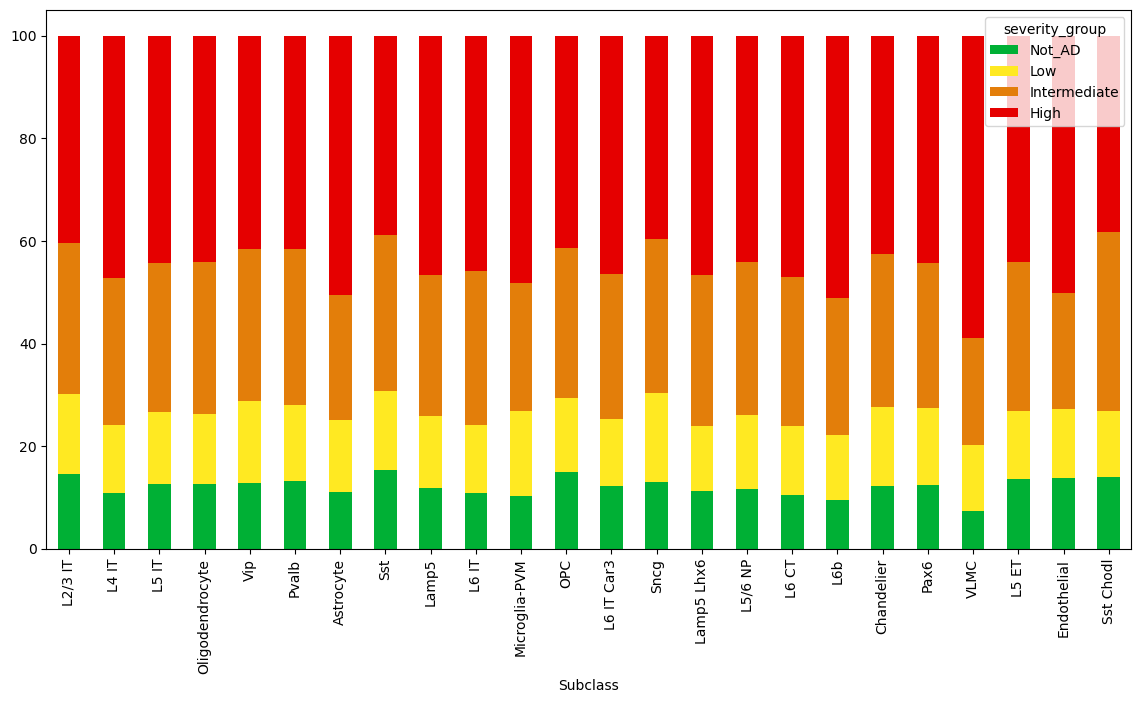

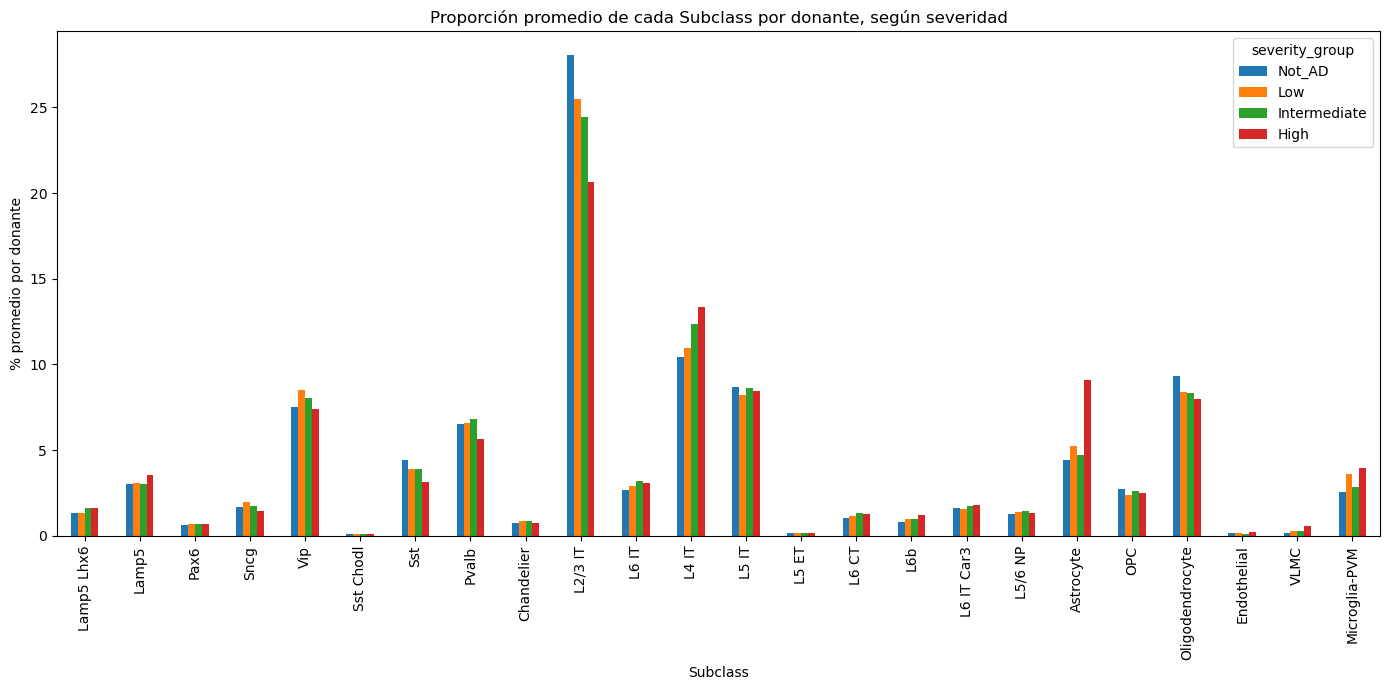

In [9]:
import pandas as pd
from pathlib import Path

# --- Tabla base: donor_id + CPS (deduplicada) ---
cps_por_donante = (
    adata.obs[['donor_id', 'Continuous Pseudo-progression Score']]
    .drop_duplicates()
    .reset_index(drop=True)
)



# --- Merge final ---
metadata_donante = cps_por_donante
metadata_donante = metadata_donante.sort_values('Continuous Pseudo-progression Score').reset_index(drop=True)

print(metadata_donante.shape)
print(metadata_donante)

# --- Guardar ---
output_path = Path("donor_cps.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
metadata_donante.to_csv(output_path, index=False)
print(f"Guardado en {output_path}")

(89, 2)
      donor_id  Continuous Pseudo-progression Score
0   H19.30.001                             0.000000
1    H200.1023                             0.000000
2   H18.30.002                             0.000000
3   H19.30.002                             0.000000
4   H18.30.001                             0.000000
..         ...                                  ...
84  H21.33.009                             0.911019
85  H21.33.020                             0.911077
86  H20.33.045                             0.922354
87  H21.33.045                             0.924065
88  H20.33.020                             0.928513

[89 rows x 2 columns]
Guardado en donor_cps.csv


In [ ]:


import pandas as pd

output_dir = Path("/export/space3/users/rafadiaz/NeuroNet_AD/data/gene_lists/vip")
output_dir.mkdir(parents=True, exist_ok=True)

# adata.var.index normalmente es el Ensembl ID (gene_id)
genes_export = adata.var[['feature_name', 'feature_type']].copy()
genes_export = genes_export.reset_index()
genes_export.columns = ['gene_id', 'gene_name', 'gene_biotype']

print(genes_export.head())
print(len(genes_export))

genes_export.to_csv(output_dir / "gene_annotation_from_anndata.csv", index=False)

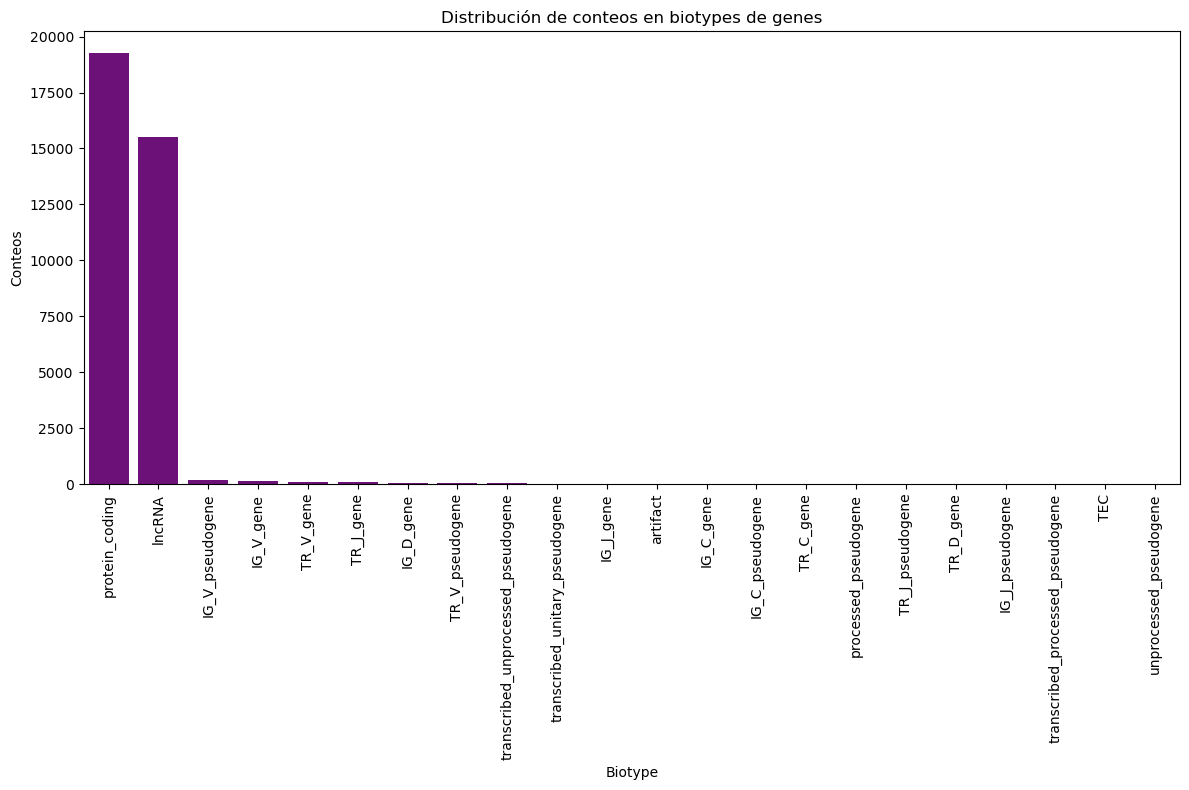

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

df_biotypes=(adata.var['feature_type'].value_counts()).reset_index()


df_biotypes.columns = ['biotype', 'count']
orden = df_biotypes['biotype'].tolist()

plt.figure(figsize=(12, 8))


sns.barplot(
    data=df_biotypes,
    x='biotype',
    y='count',
    order=orden,
    color="#790089",
    legend=False
)
plt.title('Distribución de conteos en biotypes de genes')
plt.xlabel('Biotype')
plt.ylabel('Conteos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [30]:
import scipy.sparse as sp

# ============================================================
# 1. Estado de la matriz de expresión (adata.X)
# ============================================================
print("=== Matriz de expresión (adata.X) ===")
print("Tipo:", type(adata.X))
print("Dtype:", adata.X.dtype)
print("Es sparse:", sp.issparse(adata.X))

muestra = adata.X[:5, :5].toarray() if sp.issparse(adata.X) else adata.X[:5, :5]
print("\nMuestra de valores (5x5):")
print(muestra)

print("\nMin:", adata.X.min())
print("Max:", adata.X.max())


# ============================================================
# 2. Layers y raw
# ============================================================
print("\n=== Layers y raw ===")
print("Layers disponibles:", list(adata.layers.keys()))

if adata.raw is not None:
    print("\nadata.raw existe. Muestra de adata.raw.X (5x5):")
    raw_muestra = adata.raw.X[:5, :5].toarray() if sp.issparse(adata.raw.X) else adata.raw.X[:5, :5]
    print(raw_muestra)
    print("Min:", adata.raw.X.min(), "Max:", adata.raw.X.max())
else:
    print("adata.raw es None")


# ============================================================
# 3. Sparsity de la matriz
# ============================================================
print("\n=== Sparsity ===")
if sp.issparse(adata.X):
    nnz = adata.X.nnz
    total = adata.X.shape[0] * adata.X.shape[1]
    print(f"Sparsity: {(1 - nnz/total)*100:.2f}%")
else:
    print("La matriz no es sparse (formato denso)")


# ============================================================
# 4. Genes con expresión nula/casi nula en el subset VIP
# ============================================================
print("\n=== Expresión de genes filtrados (protein_coding + lncRNA) en células VIP ===")

# Ajusta 'genes_filtrados' y

=== Matriz de expresión (adata.X) ===
Tipo: <class 'anndata._core.sparse_dataset._CSRDataset'>
Dtype: float32
Es sparse: False

Muestra de valores (5x5):
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 4 stored elements and shape (5, 5)>
  Coords	Values
  (1, 3)	0.5285244584083557
  (1, 2)	0.7152222394943237
  (2, 3)	0.23078246414661407
  (2, 2)	0.4181644022464752


AttributeError: '_CSRDataset' object has no attribute 'min'

In [ ]:
cols = ['Class', 'Subclass', 'Supertype', 'donor_id', 'Specimen ID',
        'Number of UMIs', 'Genes detected', 'Fraction mitochrondrial UMIs',
        'assay', 'suspension_type']

obs = adata.obs[cols].copy()
print(obs.dtypes)
print(obs.isna().sum())

In [ ]:

# Conteos globales por Subclass
print(obs['Subclass'].value_counts())
print()

# # Filtrado a VIP
# vip = obs[obs['Subclass'].str.contains('Vip', case=False, na=False)]

# # Conteos por Supertype dentro de VIP
# print(vip['Supertype'].value_counts())
# print()

# print(f"Total células VIP: {len(vip)} de {len(obs)} ({len(vip)/len(obs)*100:.2f}%)")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_subclass_counts = obs['Subclass'].value_counts().reset_index()
df_subclass_counts.columns = ['Subclass', 'count']
orden = df_subclass_counts['Subclass'].tolist()

plt.figure(figsize=(12, 6))


sns.barplot(
    data=df_subclass_counts,
    x='Subclass',
    y='count',
    order=orden,
    hue='Subclass',
    palette='viridis',
    legend=False
)
plt.title('Distribución de conteos en subcalss')
plt.xlabel('Subclass')
plt.ylabel('Conteos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()






In [ ]:
df_supertype_counts = obs['Supertype'].value_counts().reset_index()
df_supertype_counts.columns = ['Supertype', 'count']

df_supertype_counts = df_supertype_counts.sort_values('count', ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(
    data=df_supertype_counts,
    x='Supertype',
    y='count',
    order=df_supertype_counts['Supertype'],
    hue='Supertype',
    palette='viridis',
    legend=False
)
plt.title('Distribución de conteos en supertypes')
plt.xlabel('Supertypes')
plt.ylabel('Conteos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

vip = obs[obs['Subclass'] == 'Vip']

vip['Supertype'] = vip['Supertype'].cat.remove_unused_categories()

df_vip_supertype_counts = vip['Supertype'].value_counts().reset_index()
df_vip_supertype_counts.columns = ['Supertype', 'count']

df_vip_supertype_counts= df_vip_supertype_counts[df_vip_supertype_counts['count']>0]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_vip_supertype_counts,
    x='Supertype',
    y='count',
    hue='Supertype',
    palette='viridis',
    legend=False
)
plt.title('Distribución de conteos en supertypes (Vip)')
plt.xlabel('Supertypes')
plt.ylabel('Conteos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
data_annotation = Path("/export/space3/users/silvanac/NeuroNet_AD/data/gene_lists/vip/all_genes_annotation.csv")
annotations = pd.read_csv(data_annotation)
biotype= annotations["gene_biotype"]
annotations["gene_biotype"].value_counts()

In [ ]:
import pandas as pd
from pathlib import Path

base = Path("/export/space3/users/rafadiaz/NeuroNet_AD/data/gene_lists/vip/annotations")

protein_coding = pd.read_csv(base / "gene_annotation_protein_coding.csv")
lncrna = pd.read_csv(base / "gene_annotation_lncRNA.csv")

print(f"protein_coding: {len(protein_coding)} filas")
print(f"lncRNA: {len(lncrna)} filas")

annot_filtrado = pd.concat([protein_coding, lncrna], ignore_index=True)
print(f"\nTotal combinado: {len(annot_filtrado)} filas")

# ¿Hay gene_id duplicados exactos entre los dos archivos? (no debería, pero por si acaso)
dup_ids = annot_filtrado['gene_id'].duplicated().sum()
print(f"gene_id duplicados (filas repetidas exactas): {dup_ids}")

# Verificación clave: gene_name con múltiples gene_id distintos
dup_por_nombre = (
    annot_filtrado
    .dropna(subset=['gene_name'])
    .groupby('gene_name')['gene_id']
    .nunique()
)
dup_por_nombre = dup_por_nombre[dup_por_nombre > 1]

print(f"\ngene_name con más de un gene_id asociado: {len(dup_por_nombre)}")
print(f"Filas 'extra' que esto genera: {dup_por_nombre.sum() - len(dup_por_nombre)}")

# Cuántas filas tienen gene_name vacío/NaN (no deberían inflar duplicados por nombre)
sin_nombre = annot_filtrado['gene_name'].isna().sum()
print(f"\nFilas sin gene_name (NaN): {sin_nombre}")

# Muestra de los genes duplicados por nombre, para inspección
print(f"protein_coding: {len(protein_coding)}")
print(f"lncRNA: {len(lncrna)}")
print(f"Total (protein_coding + lncRNA): {len(annot_filtrado)}")
print(f"gene_name con múltiples gene_id: {len(dup_por_nombre)}")
print(f"Filas sin gene_name (solo gene_id): {sin_nombre}")
    
